<a href="https://colab.research.google.com/github/SenTier1107/Appprogramming_2026/blob/main/0417_FastAPI_Prerequisites/Python_Backend_Essentials_for_FastAPI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Python 핵심 개념 종합 보고서

---

##  목차

| # | 주제 | 핵심 키워드 |
|---|------|------------|
| 1 | **데코레이터 (Decorator)** | `@`, 함수를 인자로 받는 함수, 레지스트리 패턴 |
| 2 | **타입 힌트 (Type Hints)** | `str`, `int`, `list[T]`, `Optional`, `Union` |
| 3 | **Pydantic** | `BaseModel`, 런타임 유효성 검사, dataclass 비교 |
| 4 | **SQLite3 기초** | CRUD, `connect`, `cursor`, `commit` |
| 5 | **SQLite3 + Pydantic 연동** | `row_factory`, `model_validate`, 도트 접근 |
| 6 | **동기 vs 비동기** | `sync`, `async/await`, `asyncio`, `aiohttp` |
| 7 | **Gradio UI** | `gr.Interface`, `launch()`, 웹 UI 자동 생성 |

---
> **실행 환경**: Google Colab (Python 3.10+)  
> **필수 설치**: `pydantic`, `gradio`, `aiohttp` (각 섹션 상단에서 설치)

---
#  1. 데코레이터 (Decorator)

## 개념 요약
- **데코레이터**란 다른 함수를 인자로 받아 기능을 추가하거나 변형하는 함수입니다.
- `@데코레이터명` 문법을 사용하면, 함수 정의 시점에 자동으로 데코레이터가 실행됩니다.
- 대표적인 활용: **함수 등록/수집**, 로깅, 권한 검사, 캐싱 등

## 동작 원리
```
@register        ←→        register(f1)
def f1(): ...              (동일한 동작)
```

>  **FastAPI, Flask** 등 웹 프레임워크에서 라우트를 등록할 때 `@app.get("/")` 형태로 데코레이터를 광범위하게 사용합니다.

### 1-1. 수작업 방식 — `collect(func)` 직접 호출

In [ ]:
collected_functions = []  # 수집된 함수들을 저장할 리스트

def collect(func):
    """함수를 리스트에 수집하는 함수 — 데코레이터의 역할을 직접 수행"""
    print(f'수집 중: {func.__name__}')
    collected_functions.append(func)
    return func  # 원본 함수를 그대로 반환 (중요!)

def f1():
    print('running f1()')

def f2():
    print('running f2()')

# 수작업으로 직접 등록
collect(f1)
collect(f2)

print(f'\n수집된 함수 목록: {collected_functions}')

수집 중: f1
수집 중: f2

수집된 함수 목록: [<function f1 at 0x79093b08b1a0>, <function f2 at 0x79093b08b240>]


### 1-2. `@` 데코레이터 문법 — 함수 정의와 동시에 자동 등록

`@register` 한 줄로 수작업을 완전히 대체합니다.  
**모듈이 로드되는 시점**에 즉시 실행되는 점에 주목하세요.

In [ ]:
registry = []  # 함수들이 저장될 레지스트리

def register(func):
    """데코레이터 함수: 모듈 로드 시 즉시 실행되어 함수를 registry에 등록"""
    print(f'▶ 등록됨: {func.__name__}')
    registry.append(func)
    return func  # 원본 함수를 그대로 반환 — 동작은 변경하지 않음

@register          # ← 이 줄이 실행될 때 register(f1)이 즉시 호출됨
def f1():
    print('running f1()')

@register
def f2():
    print('running f2()')

@register
def f3():
    print('running f3()')

print(f'\n최종 레지스트리: {registry}')
print(f'등록된 함수 이름: {[f.__name__ for f in registry]}')

▶ 등록됨: f1
▶ 등록됨: f2
▶ 등록됨: f3

최종 레지스트리: [<function f1 at 0x79093b08a0c0>, <function f2 at 0x79093b08a480>, <function f3 at 0x79093b08b600>]
등록된 함수 이름: ['f1', 'f2', 'f3']


---
#  2. 타입 힌트 (Type Hints)

## 개념 요약
- Python 3.5+부터 지원하는 **코드 가독성 향상 도구**입니다.
- 런타임 동작에 영향을 주지 않지만, IDE 자동완성·정적 분석·FastAPI 자동 문서화에 핵심 역할을 합니다.
- **타입 힌트만 잘 이해해도 FastAPI 코드의 80%를 읽을 수 있습니다.**

| 구문 | 의미 |
|------|------|
| `name: str` | 변수 타입 선언 |
| `def f(x: int) -> str:` | 인자 타입 + 반환 타입 |
| `list[float]` | float만 담긴 리스트 |
| `str \| None` | str 또는 None (Python 3.10+) |
| `Optional[int]` | int 또는 None (3.10 미만) |

### 2-1. 기본 선언 — 변수와 함수

In [ ]:
# 함수 매개변수와 반환값에 타입 힌트 적용
def greeting(name: str) -> str:
    """name은 str, 반환값도 str임을 명시"""
    return f"Hello, {name}"

def surface_area_of_cube(edge_length: float) -> str:
    """float를 받아 str을 반환하는 함수"""
    return f"정육면체 겉넓이: {6 * edge_length ** 2}"

print(greeting(name='Gemini'))
print(surface_area_of_cube(edge_length=4.0))

# 반환값 타입 확인
res = surface_area_of_cube(4.0)
print(f'반환 타입: {type(res)}')

Hello, Gemini
정육면체 겉넓이: 96.0
반환 타입: <class 'str'>


### 2-2. 컬렉션 타입 — `list`, `dict`, `tuple`

Python 3.9+부터 `List[float]` 대신 `list[float]`처럼 기본 키워드를 바로 사용할 수 있습니다.

In [ ]:
# type alias: Vector는 float 리스트
type Vector = list[float]

def scale(scalar: float, vector: Vector) -> Vector:
    """벡터의 모든 요소에 스칼라를 곱함"""
    return [scalar * num for num in vector]

# 기본 컬렉션 타입 선언
names: list[str] = ["Alice", "Bob", "Charlie"]          # str만 담긴 리스트
user_scores: dict[str, int] = {"Alice": 100, "Bob": 90}  # 키: str, 값: int
user_info: tuple[int, str] = (1, "Admin")                # 순서/타입 고정 튜플

print(f'scale 결과: {scale(2.0, [1.0, -4.2, 5.4])}')
print(f'names: {names}')
print(f'user_scores: {user_scores}')
print(f'user_info: {user_info}')

scale 결과: [2.0, -8.4, 10.8]
names: ['Alice', 'Bob', 'Charlie']
user_scores: {'Alice': 100, 'Bob': 90}
user_info: (1, 'Admin')


### 2-3. Optional과 Union — 선택적 타입

FastAPI에서 가장 많이 등장하는 패턴입니다.  
- `str | None` : str이거나 None (Python 3.10+ 권장)
- `Optional[str]` : `Union[str, None]`의 줄임 표현

In [ ]:
from typing import Union, Optional

# Python 3.10+ 방식: | 기호 사용
def get_item(item_id: int, description: str | None = None) -> dict:
    """description은 있을 수도, 없을 수도 있음"""
    return {"id": item_id, "desc": description}

# Union: 여러 타입 중 하나
def get_user(user_id: Union[int, str]) -> dict:
    """user_id가 숫자일 수도, 문자열일 수도 있음"""
    return {"id": user_id}

# Optional 활용
def greeting_opt(name: str, enthusiasm: Optional[int] = None) -> str:
    if enthusiasm is None:
        return f"Hello, {name}."
    return f"Hello, {name}!" * enthusiasm

print(get_item(item_id=1))                         # description 생략 → None
print(get_item(item_id=1, description='test'))     # description 전달
print(get_user(user_id=1))                         # int 전달
print(get_user(user_id='abc'))                     # str 전달
print(greeting_opt("Alice", 3))                    # 3번 반복

{'id': 1, 'desc': None}
{'id': 1, 'desc': 'test'}
{'id': 1}
{'id': 'abc'}
Hello, Alice!Hello, Alice!Hello, Alice!


---
#  3. Pydantic — 런타임 데이터 유효성 검사

## 개념 요약
- **`dataclass`**: 타입 힌트를 작성하지만, 런타임에는 타입 검사를 하지 않습니다.
- **`Pydantic BaseModel`**: 인스턴스 생성 시 **자동으로 타입을 검증하고 변환**합니다.
- FastAPI는 Pydantic 모델을 타입 힌트로 사용하여 JSON 파싱·검증·문서화를 자동 처리합니다.

| | dataclass | Pydantic |
|--|-----------|----------|
| 런타임 타입 검사 | X | O |
| 자동 타입 변환 | X | O |
| 유효성 오류 예외 | X | O `ValidationError` |
| FastAPI 연동 | △ | O 완벽 지원 |

In [ ]:
# Pydantic 설치 (Colab에는 기본 설치되어 있을 수 있음)
!pip install pydantic --quiet
print('설치 완료')

설치 완료


### 3-1. dataclass — 타입 검사 없음

In [ ]:
import dataclasses

@dataclasses.dataclass
class DataUser:
    """타입 힌트는 있지만, 런타임 유효성 검사는 없음"""
    id: int
    name: str
    is_active: bool = True

print("=" * 40)
print(" dataclass 결과")
print("=" * 40)

# (1) 정상 데이터
user_data = DataUser(id=1, name="Alice")
print(f"✅ 정상: {user_data}")

# (2) 비정상 데이터 — name에 int를 넣어도 오류 없이 저장됨!
invalid_user = DataUser(id=2, name=123)  # str 자리에 int 입력
print(f"⚠️  타입 오류 무시 (저장됨): {invalid_user}")
print(f"   name의 실제 타입: {type(invalid_user.name)}")  # int 그대로!

 dataclass 결과
✅ 정상: DataUser(id=1, name='Alice', is_active=True)
⚠️  타입 오류 무시 (저장됨): DataUser(id=2, name=123, is_active=True)
   name의 실제 타입: <class 'int'>


### 3-2. Pydantic BaseModel — 런타임 검증 + 자동 변환

In [ ]:
from pydantic import BaseModel, ValidationError

class PydanticUser(BaseModel):
    """Pydantic: 인스턴스 생성 시 즉시 타입 검증 및 강제 변환"""
    id: int
    name: str
    is_active: bool = True

print("=" * 40)
print(" Pydantic 결과")
print("=" * 40)

# (1) 정상 데이터
p_user = PydanticUser(id=1, name="Bob")
print(f"✅ 정상: {p_user}")

# (2) 타입 강제 변환 — str '2'가 int로 자동 변환됨
p_user_coerce = PydanticUser(id='2', name="Charlie")  # '2' → 2 로 자동 변환
print(f"🔄 자동 변환 (str→int): {p_user_coerce}")
print(f"   id 타입: {type(p_user_coerce.id)}")  # int!

# (3) 유효성 검사 실패 — ValidationError 발생
try:
    PydanticUser(id=3, name="David", is_active="not_a_bool")  # bool로 변환 불가
except ValidationError as e:
    print(f"❌ 검증 실패: {e.errors()[0]['msg']}")

 Pydantic 결과
✅ 정상: id=1 name='Bob' is_active=True
🔄 자동 변환 (str→int): id=2 name='Charlie' is_active=True
   id 타입: <class 'int'>
❌ 검증 실패: Input should be a valid boolean, unable to interpret input


### 3-3. FastAPI 스타일 — Pydantic 모델을 타입 힌트로 사용

In [ ]:
from pydantic import BaseModel
from typing import Optional

class Item(BaseModel):
    """FastAPI의 요청 Body 스키마 정의 예시"""
    name: str
    price: float
    is_offer: Optional[bool] = None

# FastAPI에서는 아래처럼 함수 인자에 Pydantic 모델을 타입 힌트로 지정
def create_item(item: Item) -> dict:
    """FastAPI가 JSON → Item 변환을 자동으로 처리해 줌"""
    return {"item_name": item.name, "item_price": item.price}

# 테스트 실행
result = create_item(item=Item(name="Foo", price=50.2))
print(f"결과: {result}")

# Pydantic의 직렬화 기능
item = Item(name="Bar", price=9.99, is_offer=True)
print(f"\nJSON 직렬화: {item.model_dump_json()}")

결과: {'item_name': 'Foo', 'item_price': 50.2}

JSON 직렬화: {"name":"Bar","price":9.99,"is_offer":true}


---
#  4. SQLite3 기초 — CRUD 완전 정복

## 개념 요약
- **SQLite3**는 별도 서버 없이 **파일 하나로 동작**하는 경량 DB입니다.
- Python 표준 라이브러리에 포함 → 별도 설치 불필요
- 모든 DB 조작은 **CRUD** 4가지로 요약됩니다.

| 동작 | SQL | 설명 |
|------|-----|------|
| **C**reate | `INSERT INTO` | 데이터 삽입 |
| **R**ead | `SELECT` | 데이터 조회 |
| **U**pdate | `UPDATE SET` | 데이터 수정 |
| **D**elete | `DELETE FROM` | 데이터 삭제 |

### 4-1. DB 초기화 — `init_db()`

- `sqlite3.connect()`: 파일이 없으면 자동 생성
- `cursor`: SQL 명령을 실행하는 객체
- `conn.commit()`: 변경사항 확정 (필수!)

In [ ]:
import sqlite3
import os

DB_NAME = "test_sqlite3.db"

def init_db():
    """DB 파일 초기화 + 테이블 생성"""
    # 이전 파일이 있으면 삭제 (깨끗한 시작)
    if os.path.exists(DB_NAME):
        os.remove(DB_NAME)
        print(f"기존 DB 파일 삭제: {DB_NAME}")

    # 1. DB 연결 — 파일이 없으면 자동 생성
    conn = sqlite3.connect(DB_NAME)

    # 2. Cursor 생성 — SQL 실행 담당
    cursor = conn.cursor()

    # 3. 테이블 생성
    cursor.execute("""
        CREATE TABLE users (
            id       INTEGER PRIMARY KEY,
            name     TEXT NOT NULL,
            fullname TEXT
        )
    """)

    conn.commit()  # ← 이 줄 없으면 변경사항이 저장되지 않음!
    print(f"✅ DB 초기화 완료: {DB_NAME}")
    return conn

conn = init_db()
cursor = conn.cursor()

✅ DB 초기화 완료: test_sqlite3.db


### 4-2. C — Create (데이터 삽입)

`executemany()`: 리스트 데이터를 한 번에 여러 행으로 삽입 (효율적!)  
`?`: SQL 인젝션 방지를 위한 파라미터 바인딩

In [ ]:
users_data = [
    ('spongebob', 'Spongebob Squarepants'),
    ('patrick',   'Patrick Star'),
    ('squidward', 'Squidward Tentacles'),
]

# executemany: 리스트를 반복하며 여러 행 한 번에 삽입
cursor.executemany(
    "INSERT INTO users (name, fullname) VALUES (?, ?)",  # ? = 파라미터 바인딩
    users_data
)
conn.commit()
print(f"✅ {len(users_data)}개 데이터 삽입 완료")

✅ 3개 데이터 삽입 완료


### 4-3. R — Read (데이터 조회)

- `fetchall()`: 모든 행을 리스트로 반환
- `fetchone()`: 첫 번째 행 하나만 반환
- 결과는 **튜플** 형식 → 인덱스로 컬럼 접근

In [ ]:
# 전체 조회 — fetchall()
print("── 전체 조회 ──")
cursor.execute("SELECT id, name, fullname FROM users")
rows = cursor.fetchall()

for row in rows:
    print(f"  ID: {row[0]}, Name: {row[1]}, FullName: {row[2]}")

# 조건 조회 — WHERE + fetchone()
print("\n── 조건 조회 (WHERE) ──")
cursor.execute(
    "SELECT * FROM users WHERE name = ?",
    ('patrick',)   # 튜플 주의: 쉼표 필수 → ('patrick',)
)
patrick = cursor.fetchone()
print(f"  Patrick 조회 결과: {patrick}")

── 전체 조회 ──
  ID: 1, Name: spongebob, FullName: Spongebob Squarepants
  ID: 2, Name: patrick, FullName: Patrick Star
  ID: 3, Name: squidward, FullName: Squidward Tentacles

── 조건 조회 (WHERE) ──
  Patrick 조회 결과: (2, 'patrick', 'Patrick Star')


In [ ]:
new_fullname = 'S. Squarepants'

cursor.execute(
    "UPDATE users SET fullname = ? WHERE name = ?",
    (new_fullname, 'spongebob')  # 수정할 값, 조건값 순서
)
conn.commit()

# 수정 결과 확인
cursor.execute("SELECT * FROM users WHERE name = 'spongebob'")
print(f"✅ 수정 후: {cursor.fetchone()}")

✅ 수정 후: (1, 'spongebob', 'S. Squarepants')


### 4-5. D — Delete (데이터 삭제)

>

In [ ]:
cursor.execute(
    "DELETE FROM users WHERE name = ?",
    ('squidward',)
)
conn.commit()

# 최종 데이터 확인
print("── 삭제 후 최종 데이터 ──")
cursor.execute("SELECT * FROM users")
for row in cursor.fetchall():
    print(f"  {row}")
print("✅ squidward 삭제 완료")

── 삭제 후 최종 데이터 ──
  (1, 'spongebob', 'S. Squarepants')
  (2, 'patrick', 'Patrick Star')
✅ squidward 삭제 완료


---
#  5. SQLite3 + Pydantic 연동

## 개념 요약
- SQLite3에서 가져온 데이터는 기본적으로 **tuple** 형태입니다.
- `conn.row_factory = sqlite3.Row` 설정으로 **dict처럼** 접근 가능하게 합니다.
- Pydantic `model_validate()`로 Row 데이터를 모델 객체로 변환하면:
  - `row['name']` (딕셔너리 방식) → `user.name` (**도트 연산자** 방식)
  - 자동 타입 검증 + IDE 자동완성 지원

In [ ]:
import sqlite3
from pydantic import BaseModel, ConfigDict
from typing import Optional

# ── 1. Pydantic 모델 정의 ──
class User(BaseModel):
    id: int
    name: str
    email: str
    age: Optional[int] = None

    # SQLite Row 객체를 dict처럼 처리하기 위한 Pydantic v2 설정
    model_config = ConfigDict(from_attributes=True)

# ── 2. 메모리 DB 초기화 (테스트용) ──
def init_db_mem():
    conn = sqlite3.connect(":memory:")  # 메모리 DB: 프로그램 종료 시 자동 삭제
    cursor = conn.cursor()
    cursor.execute("""
        CREATE TABLE users (
            id INTEGER PRIMARY KEY,
            name TEXT,
            email TEXT,
            age INTEGER
        )
    """)
    cursor.execute("INSERT INTO users VALUES (1, 'Alice', 'alice@example.com', 25)")
    cursor.execute("INSERT INTO users VALUES (2, 'Bob',   'bob@example.com',   NULL)")
    conn.commit()
    return conn

# ── 3. 조회 + Pydantic 변환 ──
def get_users_pydantic(conn) -> list[User]:
    conn.row_factory = sqlite3.Row  # ← dict처럼 접근 가능하게 설정
    cursor = conn.cursor()
    cursor.execute("SELECT * FROM users")
    rows = cursor.fetchall()
    # dict(row)로 변환 후 Pydantic 모델로 검증
    return [User.model_validate(dict(row)) for row in rows]

# ── 실행 ──
connection = init_db_mem()
user_list = get_users_pydantic(connection)

print("── Pydantic 모델로 변환된 결과 ──")
for user in user_list:
    # row['name'] 대신 user.name — 도트 연산자로 접근!
    print(f"  ID: {user.id} | 이름: {user.name} | 이메일: {user.email} | 나이: {user.age}")

── Pydantic 모델로 변환된 결과 ──
  ID: 1 | 이름: Alice | 이메일: alice@example.com | 나이: 25
  ID: 2 | 이름: Bob | 이메일: bob@example.com | 나이: None


---
#  6. 동기(Sync) vs 비동기(Async)

## 개념 요약

 **커피샵 비유**
- **동기(sync)**: 친구 옆에 서서 커피 받을 때까지 기다린다
- **비동기(async)**: 친구가 커피 가져오는 동안 나는 다른 일을 한다

| 항목 | 동기 (Sync) | 비동기 (Async) |
|------|------------|----------------|
| 처리 방식 | 순차 (하나씩) | 동시 (한꺼번에) |
| 완료 순서 | 항상 요청 순서 | 빠른 것부터 |
| 소요 시간 | 파일 수 × 개당 시간 | ≈ 가장 느린 1개의 시간 |
| 코드 복잡도 | 단순 | `async/await` 필요 |

## 핵심 키워드
- **`async def`**: 비동기 함수(코루틴) 정의
- **`await`**: "이 작업 끝날 때까지 잠깐 대기, 그 동안 다른 작업 해도 됨"
- **`asyncio.gather()`**: 여러 코루틴을 동시에 실행
- **`aiohttp`**: `requests`의 비동기 버전

In [ ]:
!pip install aiohttp --quiet
print('설치 완료')

설치 완료


### 6-1. 공통 설정 — CSV URL 목록 수집

In [ ]:
import os
import time
import requests
import aiohttp
import asyncio
from bs4 import BeautifulSoup

def get_all_csv_urls(base_url):
    """페이지에서 .csv 링크를 모두 수집"""
    response = requests.get(base_url)
    if response.status_code != 200:
        return []
    soup = BeautifulSoup(response.text, 'html.parser')
    return [
        base_url + link.get('href')
        for link in soup.find_all('a')
        if link.get('href', '').endswith('.csv')
    ]

BASE_URL = "https://people.sc.fsu.edu/~jburkardt/data/csv/"
file_urls = get_all_csv_urls(BASE_URL)
print(f"✅ 총 {len(file_urls)}개의 CSV URL 수집 완료")

✅ 총 33개의 CSV URL 수집 완료


### 6-2. 동기 방식 다운로드 — 순차 처리

`[1] 완료 → [2] 완료 → [3] 완료 →` ... 순서가 항상 동일하게 출력됩니다.

In [ ]:
def download_file_sync(url, save_path, index):
    """단일 파일 동기 다운로드"""
    print(f"[{index:2d}] 시작: {os.path.basename(url)}")
    response = requests.get(url)
    if response.status_code == 200:
        with open(save_path, 'wb') as f:
            f.write(response.content)
        print(f"[{index:2d}] ✅ 완료")
        return save_path
    return None

def download_all_sync():
    """모든 파일 순차 다운로드"""
    results = []
    for i, url in enumerate(file_urls, start=1):
        save_path = f"./{os.path.basename(url)}"
        if download_file_sync(url, save_path, i):
            results.append(os.path.basename(save_path))
    return results

print("=" * 50)
print("동기 방식 다운로드 시작 (순서대로 처리됨)")
print("=" * 50)
t1 = time.time()
sync_results = download_all_sync()
t2 = time.time()
print(f"\n⏱ 동기 완료: {t2 - t1:.2f}초 | {len(sync_results)}개 파일")

# 다운로드 파일 정리
for f in os.listdir('./'):
    if f.endswith('.csv'): os.remove(f'./{f}')
print("🗑️  정리 완료")

동기 방식 다운로드 시작 (순서대로 처리됨)
[ 1] 시작: addresses.csv
[ 1] ✅ 완료
[ 2] 시작: airtravel.csv
[ 2] ✅ 완료
[ 3] 시작: biostats.csv
[ 3] ✅ 완료
[ 4] 시작: cities.csv
[ 4] ✅ 완료
[ 5] 시작: crash_catalonia.csv
[ 5] ✅ 완료
[ 6] 시작: deniro.csv
[ 6] ✅ 완료
[ 7] 시작: example.csv
[ 7] ✅ 완료
[ 8] 시작: faithful.csv
[ 8] ✅ 완료
[ 9] 시작: ford_escort.csv
[ 9] ✅ 완료
[10] 시작: freshman_kgs.csv
[10] ✅ 완료
[11] 시작: freshman_lbs.csv
[11] ✅ 완료
[12] 시작: grades.csv
[12] ✅ 완료
[13] 시작: homes.csv
[13] ✅ 완료
[14] 시작: hooke.csv
[14] ✅ 완료
[15] 시작: hurricanes.csv
[15] ✅ 완료
[16] 시작: hw_200.csv
[16] ✅ 완료
[17] 시작: hw_25000.csv
[17] ✅ 완료
[18] 시작: lead_shot.csv
[18] ✅ 완료
[19] 시작: letter_frequency.csv
[19] ✅ 완료
[20] 시작: mlb_players.csv
[20] ✅ 완료
[21] 시작: mlb_teams_2012.csv
[21] ✅ 완료
[22] 시작: news_decline.csv
[22] ✅ 완료
[23] 시작: nile.csv
[23] ✅ 완료
[24] 시작: oscar_age_female.csv
[24] ✅ 완료
[25] 시작: oscar_age_male.csv
[25] ✅ 완료
[26] 시작: snakes_count_10.csv
[26] ✅ 완료
[27] 시작: snakes_count_100.csv
[27] ✅ 완료
[28] 시작: snakes_count_1000.csv
[28] ✅ 완료
[29] 시작: snakes_

### 6-3. 비동기 방식 다운로드 — 동시 처리

완료 순서가 뒤섞여 출력됩니다 → **응답이 빠른 것부터** 먼저 완료됩니다.

In [ ]:
async def download_file_async(session, url, save_path, index):
    """단일 파일 비동기 다운로드"""
    print(f"[{index:2d}] 시작: {os.path.basename(url)}")
    async with session.get(url) as response:  # await 포인트: 응답 대기 중 다른 작업 실행
        if response.status == 200:
            content = await response.read()   # await 포인트: 데이터 읽기 대기 중 다른 작업 실행
            with open(save_path, 'wb') as f:
                f.write(content)
            print(f"[{index:2d}] ✅ 완료: {os.path.basename(save_path)}")
            return save_path
    return None

async def download_all_async():
    """모든 파일 동시 다운로드"""
    async with aiohttp.ClientSession() as session:
        tasks = [
            download_file_async(session, url, f"./{os.path.basename(url)}", i)
            for i, url in enumerate(file_urls, start=1)
        ]
        results = await asyncio.gather(*tasks)  # 모든 tasks를 동시에 실행!
    return [os.path.basename(r) for r in results if r]

print("=" * 50)
print("비동기 방식 다운로드 시작 (동시에 처리됨)")
print("=" * 50)
t1 = time.time()
async_results = await download_all_async()  # Colab/Jupyter에서는 await 직접 사용 가능
t2 = time.time()
print(f"\n⏱ 비동기 완료: {t2 - t1:.2f}초 | {len(async_results)}개 파일")

# 다운로드 파일 정리
for f in os.listdir('./'):
    if f.endswith('.csv'): os.remove(f'./{f}')
print("🗑️  정리 완료")

비동기 방식 다운로드 시작 (동시에 처리됨)
[ 1] 시작: addresses.csv
[ 2] 시작: airtravel.csv
[ 3] 시작: biostats.csv
[ 4] 시작: cities.csv
[ 5] 시작: crash_catalonia.csv
[ 6] 시작: deniro.csv
[ 7] 시작: example.csv
[ 8] 시작: faithful.csv
[ 9] 시작: ford_escort.csv
[10] 시작: freshman_kgs.csv
[11] 시작: freshman_lbs.csv
[12] 시작: grades.csv
[13] 시작: homes.csv
[14] 시작: hooke.csv
[15] 시작: hurricanes.csv
[16] 시작: hw_200.csv
[17] 시작: hw_25000.csv
[18] 시작: lead_shot.csv
[19] 시작: letter_frequency.csv
[20] 시작: mlb_players.csv
[21] 시작: mlb_teams_2012.csv
[22] 시작: news_decline.csv
[23] 시작: nile.csv
[24] 시작: oscar_age_female.csv
[25] 시작: oscar_age_male.csv
[26] 시작: snakes_count_10.csv
[27] 시작: snakes_count_100.csv
[28] 시작: snakes_count_1000.csv
[29] 시작: snakes_count_10000.csv
[30] 시작: tally_cab.csv
[31] 시작: taxables.csv
[32] 시작: trees.csv
[33] 시작: zillow.csv
[12] ✅ 완료: grades.csv
[25] ✅ 완료: oscar_age_male.csv
[ 6] ✅ 완료: deniro.csv
[13] ✅ 완료: homes.csv
[26] ✅ 완료: snakes_count_10.csv
[ 5] ✅ 완료: crash_catalonia.csv
[27] ✅ 완료: snakes_count

### 6-4. `await` 동작 원리 시각화

9개의 작업 합계 대기시간은 18초이지만, 비동기로 실행하면 **가장 긴 3초**만 걸립니다.

In [ ]:
import asyncio, time

async def task(name, delay):
    print(f"[{name}] 시작")
    await asyncio.sleep(delay)  # 이 순간 이벤트 루프가 다른 task로 전환됨
    print(f"[{name}] 완료 ({delay}초 후)")

print("=== 비동기: 9개 작업 동시 실행 ===")
t1 = time.time()

# asyncio.gather: 모든 task를 동시에 등록 및 실행
await asyncio.gather(
    task("A", 3), task("B", 1), task("C", 2),
    task("D", 3), task("E", 1), task("F", 2),
    task("G", 3), task("H", 1), task("I", 2),
)
t2 = time.time()

print(f"\n⏱ 총 소요: {t2 - t1:.1f}초")
print("   (순차 실행이었다면 3+1+2+3+1+2+3+1+2 = 18초 소요)")

=== 비동기: 9개 작업 동시 실행 ===
[A] 시작
[B] 시작
[C] 시작
[D] 시작
[E] 시작
[F] 시작
[G] 시작
[H] 시작
[I] 시작
[B] 완료 (1초 후)
[E] 완료 (1초 후)
[H] 완료 (1초 후)
[C] 완료 (2초 후)
[F] 완료 (2초 후)
[I] 완료 (2초 후)
[A] 완료 (3초 후)
[D] 완료 (3초 후)
[G] 완료 (3초 후)

⏱ 총 소요: 3.0초
   (순차 실행이었다면 3+1+2+3+1+2+3+1+2 = 18초 소요)


### 6-5. 실행 시간 비교 요약

| 방식 | 계산 | 예상 소요 |
|------|------|----------|
| 순차 (Sync) | 3+1+2+3+1+2+3+1+2 | **18초** |
| 비동기 (Async) | max(3,1,2,3,1,2,3,1,2) | **3초** |

---
#  7. Gradio — 파이썬 함수를 웹 UI로 즉시 변환

## 개념 요약
- **Gradio**는 ML 모델이나 파이썬 함수를 단 몇 줄로 웹 UI로 만들어주는 라이브러리입니다.
- `gr.Interface(fn=함수, inputs=입력타입, outputs=출력타입)` 구조로 사용합니다.
- `.launch()` 호출 시 로컬 + Colab 공개 URL이 자동 생성됩니다.

| 매개변수 | 역할 | 주요 옵션 |
|---------|------|----------|
| `fn` | 실행할 파이썬 함수 | 어떤 함수든 가능 |
| `inputs` | 입력 컴포넌트 | `"text"`, `"image"`, `"number"`, ... |
| `outputs` | 출력 컴포넌트 | `"text"`, `"image"`, `"label"`, ... |

In [ ]:
!pip install gradio --quiet
print('Gradio 설치 완료')

Gradio 설치 완료


### 7-1. 기본 예제 — 텍스트 입출력

In [ ]:
import gradio as gr

# 처리할 함수 정의
def greet(name: str) -> str:
    """이름을 입력받아 인사말 반환"""
    return f"Hello, {name}! 👋"

# gr.Interface: fn(함수), inputs(입력타입), outputs(출력타입)
interface = gr.Interface(
    fn=greet,
    inputs="text",
    outputs="text",
    title="인사 생성기",
    description="이름을 입력하면 인사말을 반환합니다."
)

interface.launch()  # Colab에서는 자동으로 share=True 적용

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b936028b17cb0b9865.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## **7-1_gradio_실행결과스크린샷**

---
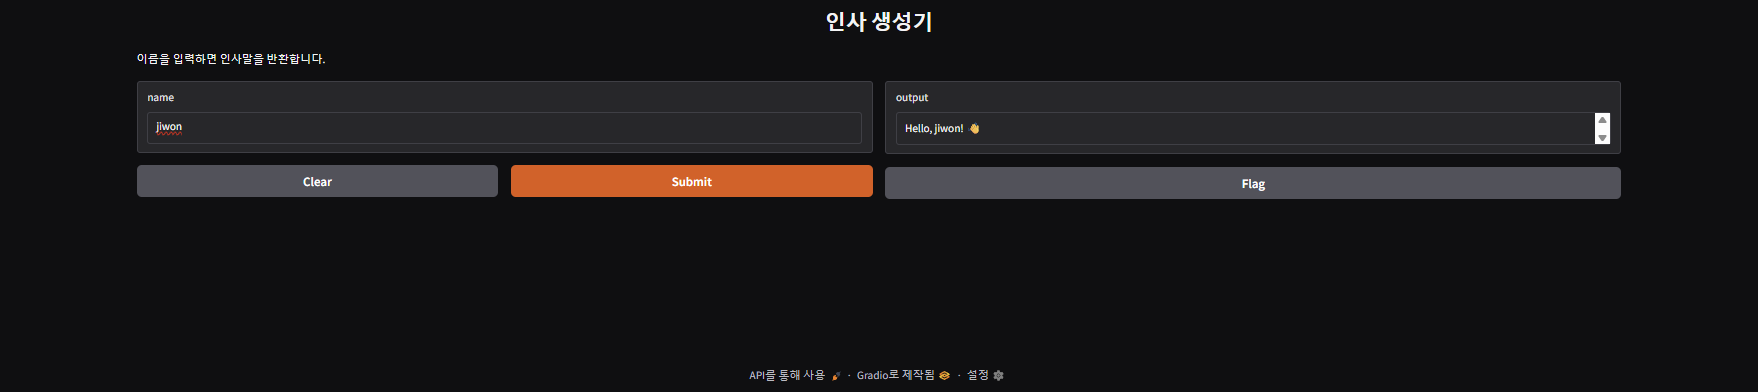


### 7-2. 이미지 처리 — 흑백 변환

In [ ]:
import gradio as gr

def image_to_grayscale(img):
    return img.convert("L")  # img가 PIL Image로 들어옴

interface_img = gr.Interface(
    fn=image_to_grayscale,
    inputs=gr.Image(type="pil"),  # ← 이 부분이 핵심
    outputs="image",
    title="흑백 변환기",
    description="이미지를 업로드하면 흑백으로 변환합니다."
)

interface_img.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://67f49d63126eb2960d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## **7-2_gradio_실행결과스크린샷**

---
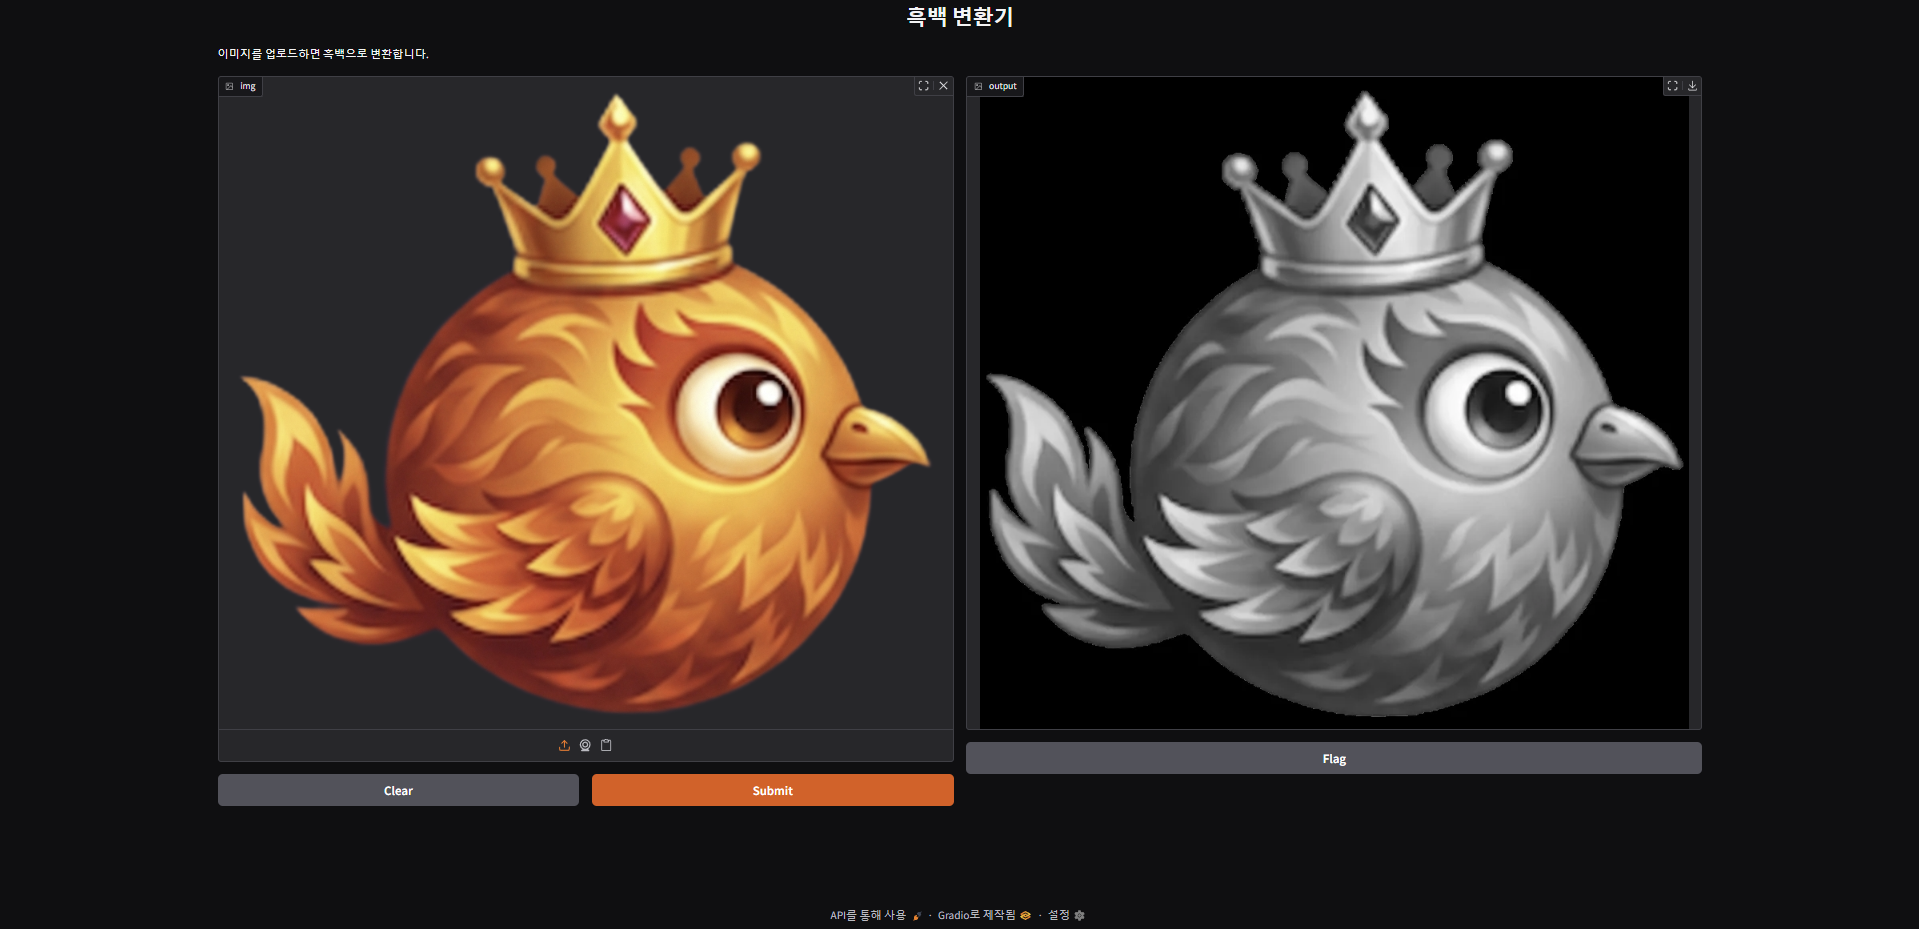

In [ ]:
import gradio as gr

def uppercase_text(text: str) -> str:
    """텍스트를 대문자로 변환"""
    return text.upper()

interface_upper = gr.Interface(
    fn=uppercase_text,
    inputs=gr.Textbox(lines=3, placeholder="변환할 텍스트 입력..."),
    outputs=gr.Textbox(label="대문자 결과"),
    title="대문자 변환기"
)

interface_upper.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5bcb5cef42bf7fab31.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## **7-3_gradio_실행결과스크린샷**

---
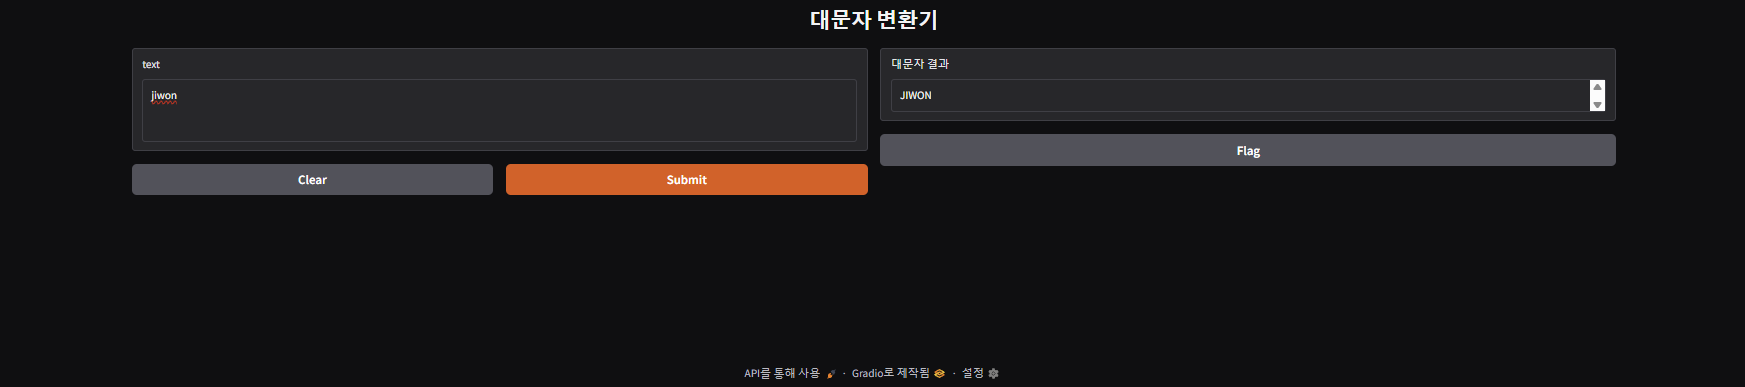

### 7-4. (선택) ngrok으로 외부 공개 URL 생성

>  **사전 준비 필요**: [ngrok.com](https://ngrok.com)에서 계정 생성 후 authtoken 발급 → Colab Secrets에 `ngrok` 키로 저장

In [ ]:
# ngrok 설치
!pip install pyngrok --quiet

import gradio as gr
import time
from pyngrok import ngrok

# ── ngrok authtoken 설정 (Colab Secrets 사용) ──
# 아래 코드는 Colab Secrets에 'ngrok' 키가 등록되어 있어야 합니다.
try:
    from google.colab import userdata
    myngrok = userdata.get('ngrok')
    ngrok.set_auth_token(myngrok)
    print("✅ ngrok 토큰 설정 완료")
except Exception as e:
    print(f"⚠️  ngrok 토큰 설정 실패: {e}")
    print("   ngrok.com에서 토큰을 발급받아 Colab Secrets에 등록하세요.")

def greet_ngrok(name: str) -> str:
    return f"안녕하세요, {name}님! 🎉"

interface = gr.Interface(fn=greet_ngrok, inputs="text", outputs="text")

ngrok.kill()    # 기존 터널 종료
time.sleep(2)
gr.close_all()  # 기존 Gradio 인터페이스 종료

# ngrok 터널 생성 (포트 7860)
tunnel = ngrok.connect(addr=7860)
print(f"🌐 외부 공개 URL: {tunnel.public_url}")

interface.launch(server_name="0.0.0.0", server_port=7860)

✅ ngrok 토큰 설정 완료
🌐 외부 공개 URL: https://worrier-repeated-unaired.ngrok-free.dev
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://424786e820275aab78.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## **7-4_gradio_실행결과스크린샷**
 위 코드 실행 시 생성된 ngrok 공개 URL(`https://worrier-repeated-unaired.ngrok-free.dev`)에   외부 브라우저로 접속한 결과입니다.

---

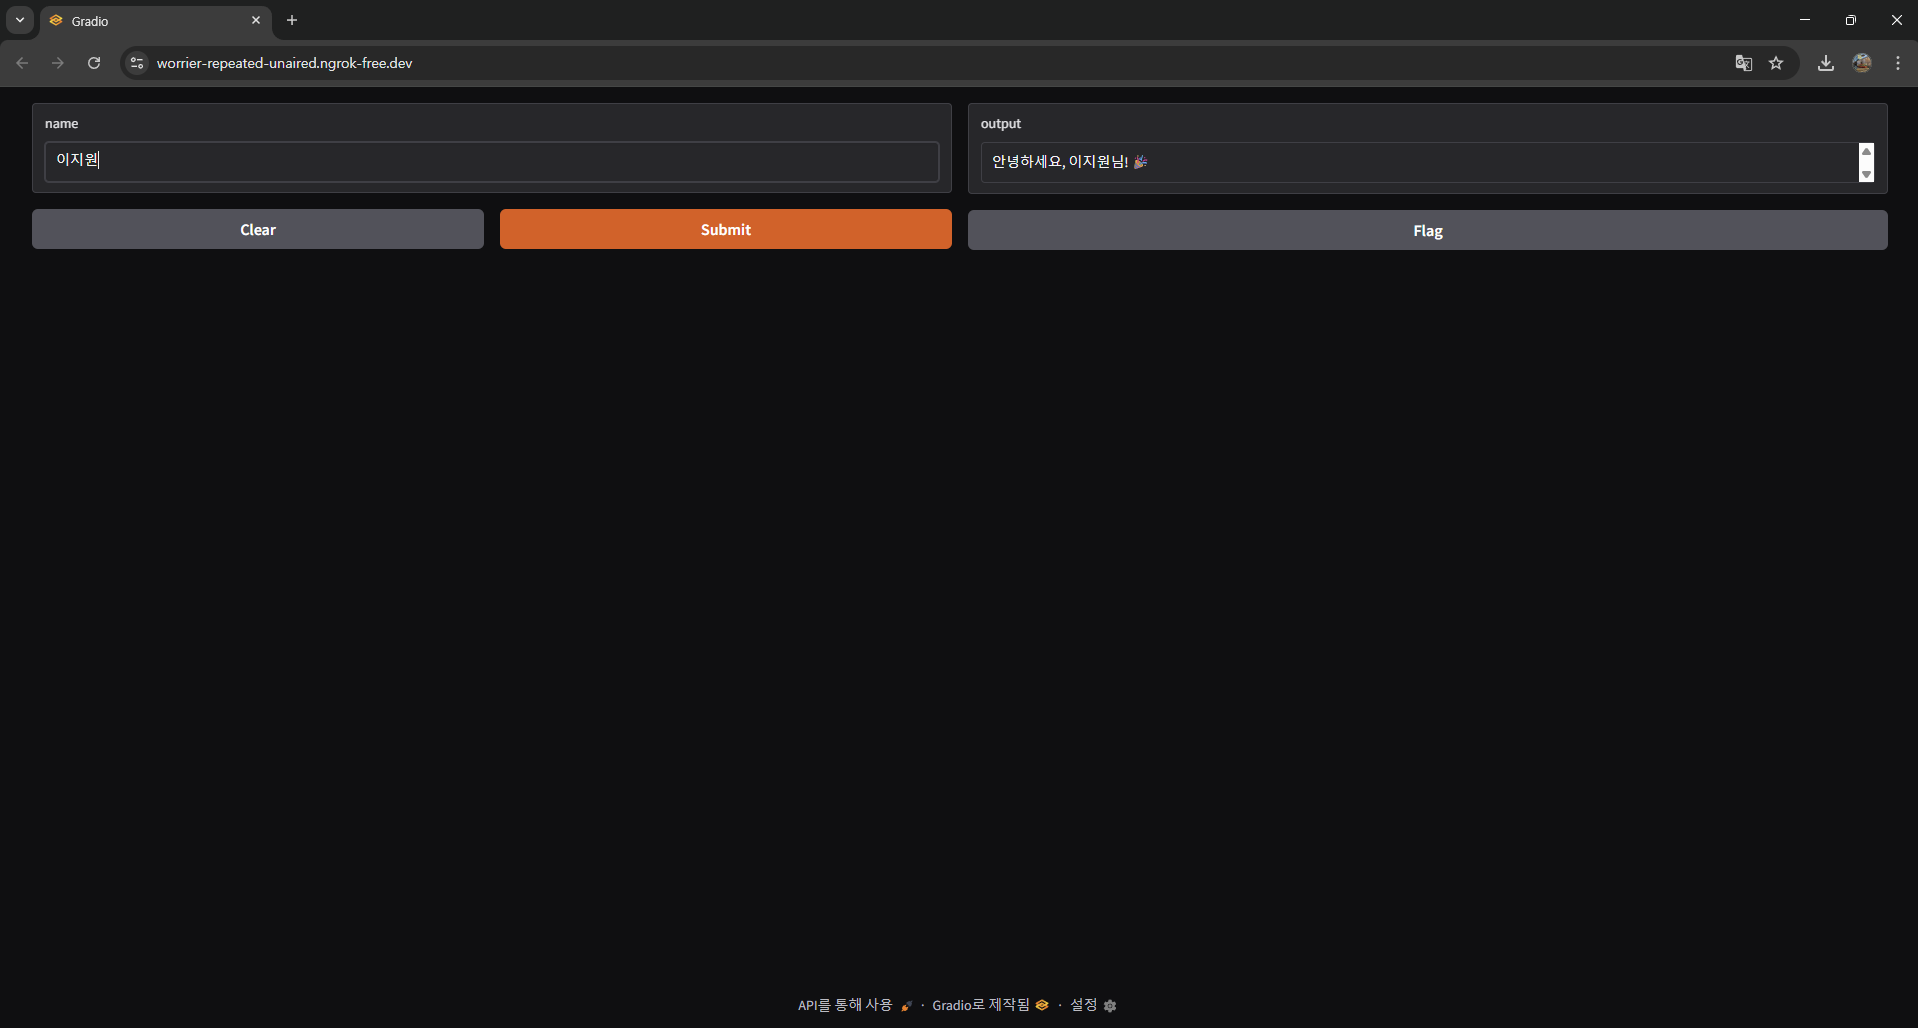

---
#  전체 요약

## 학습한 내용 정리

| 주제 | 핵심 개념 | 실무 활용 |
|------|----------|----------|
| **데코레이터** | `@func`로 함수 등록·변형 | Flask/FastAPI 라우팅, 로깅 |
| **타입 힌트** | `: 타입`, `-> 반환타입` | 코드 가독성, IDE 지원, FastAPI 자동화 |
| **Pydantic** | `BaseModel`, 런타임 검증 | FastAPI 요청/응답 스키마 |
| **SQLite3** | CRUD, `cursor`, `commit` | 로컬 DB, 프로토타입 개발 |
| **SQLite3+Pydantic** | `row_factory`, `model_validate` | DB 데이터를 안전하게 다루기 |
| **Sync/Async** | `async/await`, `asyncio.gather` | API 서버, 파일 다운로드 최적화 |
| **Gradio** | `gr.Interface`, `launch()` | ML 데모, 빠른 프로토타입 UI |

---
## 연결 흐름

```
타입 힌트  →  Pydantic (검증)  →  SQLite3 (저장)  →  FastAPI (서비스)
                                                          ↑
데코레이터 (@app.get)  ←─────────────────────────────────┘
                                                          ↓
async/await (성능)  →  Gradio (UI)  →  사용자
```